# 🏠 House Price Prediction — Linear Regression via Gradient Descent

**Dataset:** [House Prices — Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)  
We use the simplified `train.csv` from that competition, focusing on a clean subset of numeric features that have a strong linear relationship with `SalePrice`.

### Notebook Structure
| Section | Who fills it? |
|---|---|
| 1 – Setup & Data Load | ✅ Pre-filled |
| 2 – EDA & Matplotlib Visualisation | ✅ Pre-filled |
| 3 – Preprocessing | ✅ Pre-filled |
| 4 – Gradient Descent Implementation | 🖊️ **You complete this** |
| 5 – Training & Evaluation | 🖊️ **You complete this** |
| 6 – Results Visualisation | 🖊️ **You complete this** |

---
## Section 1 — Setup & Data Load

In [2]:
# ── Install/import everything we need ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error, r2_score
# import warnings
# warnings.filterwarnings('ignore')

/home/huzaifa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
df_raw = pd.read_csv("housing.csv")

---
## Section 2 — Exploratory Data Analysis & Visualisation

> All plots are pre-built so you can understand the data before implementing gradient descent.

In [6]:
# ── 2a. Dataset overview ──────────────────────────────────────────────────────
print('=== INFO ===')
df_raw.info()
print('\n=== DESCRIBE ===')
df_raw.describe().round(2)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== DESCRIBE ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


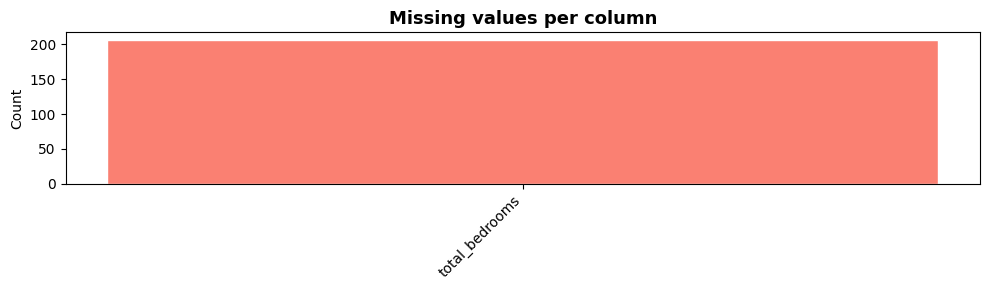

In [7]:
# ── 2b. Missing-value heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    ax.bar(missing.index, missing.values, color='salmon', edgecolor='white')
    ax.set_title('Missing values per column', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
else:
    ax.text(0.5, 0.5, 'No missing values 🎉', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

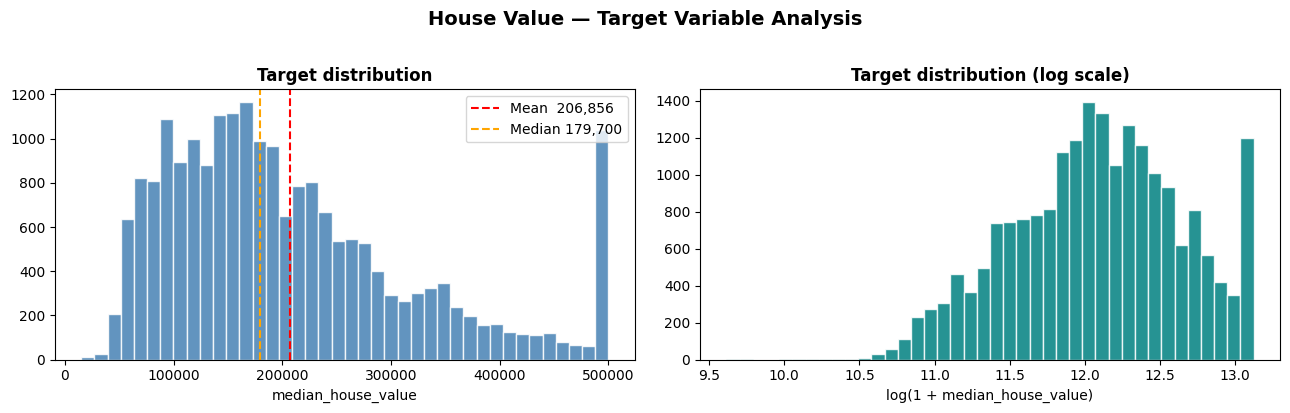

In [8]:
# ── 2c. Distribution of the target variable (median_house_value) ──────────────
target_col = 'median_house_value'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df_raw[target_col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_raw[target_col].mean(),   color='red',    linestyle='--', label=f'Mean  {df_raw[target_col].mean():,.0f}')
axes[0].axvline(df_raw[target_col].median(), color='orange', linestyle='--', label=f'Median {df_raw[target_col].median():,.0f}')
axes[0].set_title('Target distribution', fontweight='bold')
axes[0].set_xlabel(target_col)
axes[0].legend()

# Log-scale version (helps spot skew)
axes[1].hist(np.log1p(df_raw[target_col]), bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Target distribution (log scale)', fontweight='bold')
axes[1].set_xlabel(f'log(1 + {target_col})')

plt.suptitle('House Value — Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

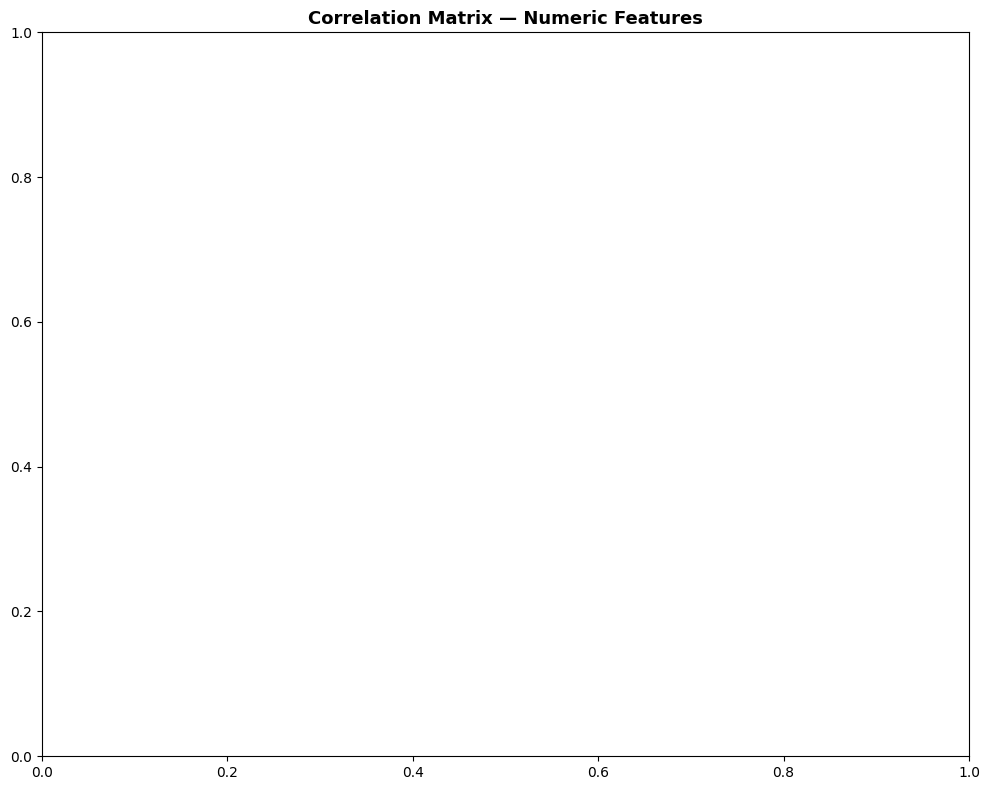


Top correlations with median_house_value :
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160


In [9]:
# ── 2d. Correlation heatmap (numeric features) ────────────────────────────────
num_df = df_raw.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(10, 8))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with target
print('\nTop correlations with', target_col, ':')
print(corr[target_col].drop(target_col).sort_values(ascending=False).to_string())

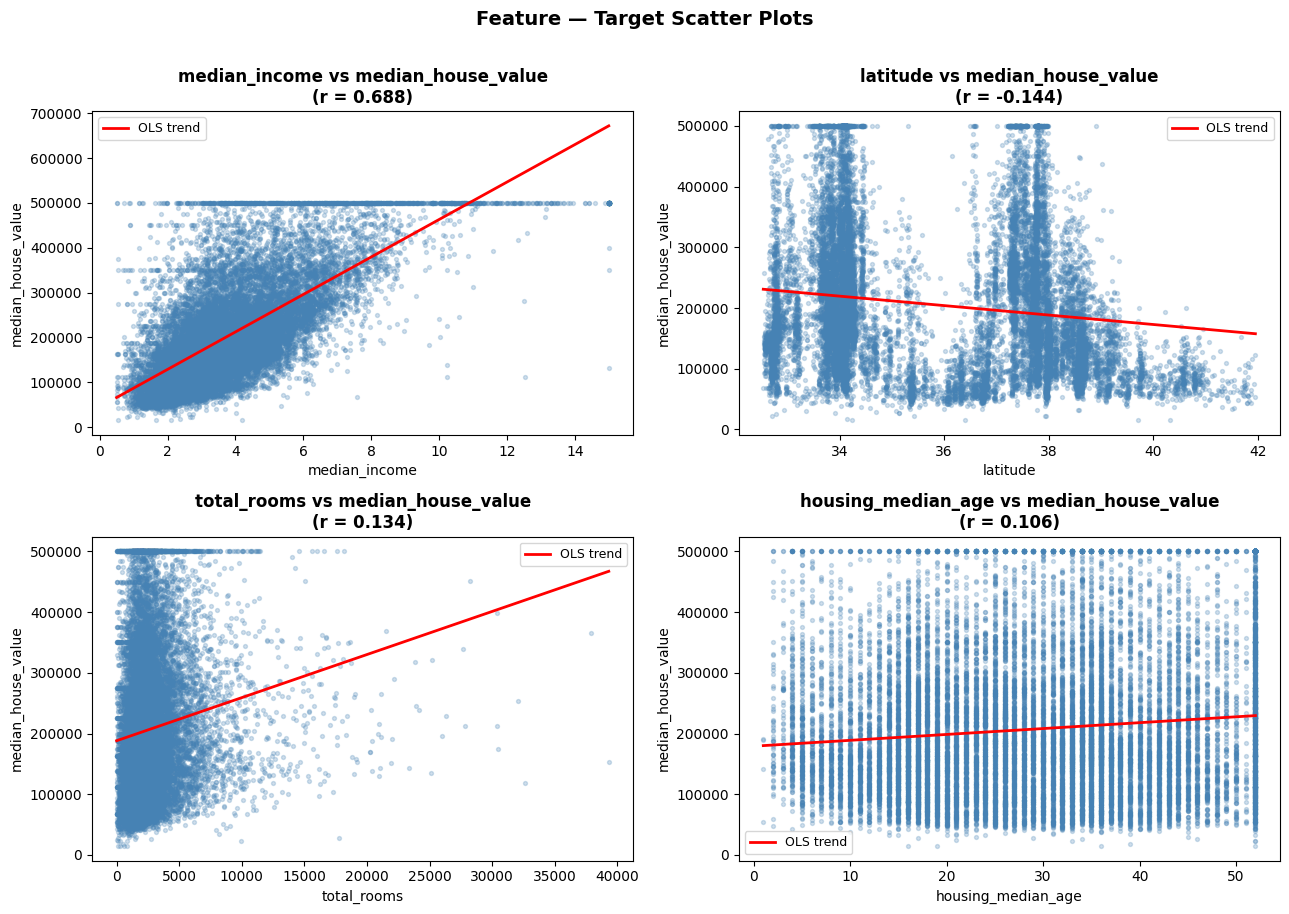

In [10]:
# ── 2e. Scatter plots — top 4 numeric features vs target ─────────────────────
top_features = (
    corr[target_col]
    .drop(target_col)
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df_raw[feat], df_raw[target_col],
                    alpha=0.25, s=8, color='steelblue')
    # Trend line
    z = np.polyfit(df_raw[feat].dropna(), df_raw.loc[df_raw[feat].notna(), target_col], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_raw[feat].min(), df_raw[feat].max(), 200)
    axes[i].plot(xs, p(xs), color='red', linewidth=2, label='OLS trend')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(target_col)
    axes[i].set_title(f'{feat} vs {target_col}\n(r = {corr.loc[feat, target_col]:.3f})', fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature — Target Scatter Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

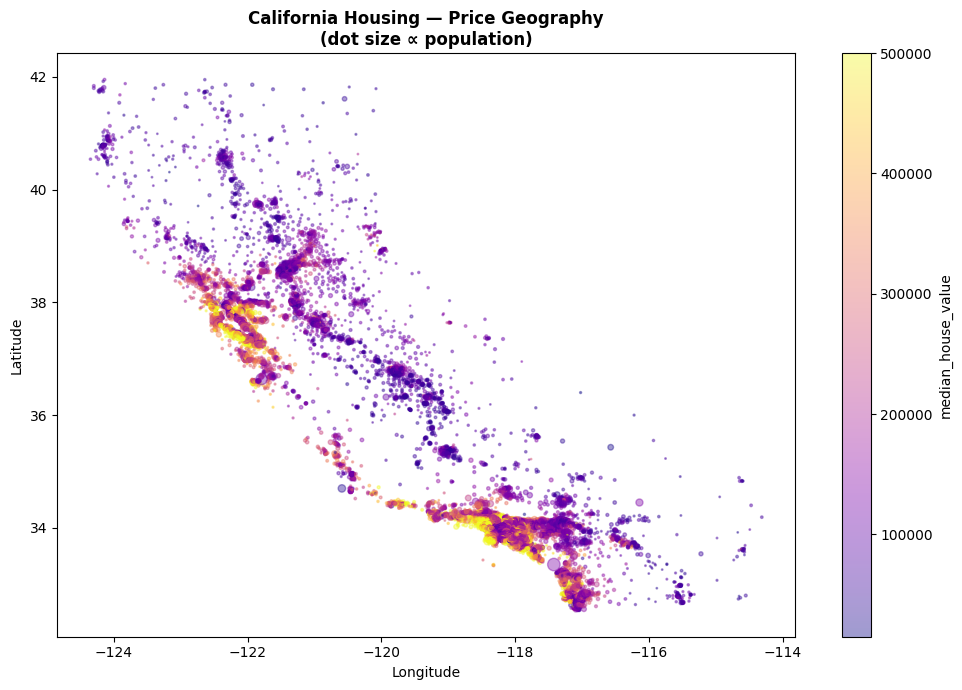

In [11]:
# ── 2f. Geographical scatter (latitude / longitude colour-coded by price) ─────
if 'latitude' in df_raw.columns and 'longitude' in df_raw.columns:
    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(
        df_raw['longitude'], df_raw['latitude'],
        c=df_raw[target_col], cmap='plasma',
        alpha=0.4, s=df_raw['population'] / df_raw['population'].max() * 80 + 1
    )
    plt.colorbar(sc, ax=ax, label=target_col)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('California Housing — Price Geography\n(dot size ∝ population)', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Section 3 — Preprocessing ✅ (Pre-filled)

We:
1. Drop the categorical `ocean_proximity` column (keep it linear-regression-clean).
2. Fill missing values with column medians.
3. Keep the **two features most correlated** with the target — great for visualising a 2-D decision boundary.
4. Standardise features with `StandardScaler` (essential for gradient descent convergence).
5. Split into train / test sets.

In [12]:
# ── 3a. Select & clean features ───────────────────────────────────────────────
FEATURE_COLS = top_features          # top 4 correlated numeric features
TARGET_COL   = target_col

df = df_raw[FEATURE_COLS + [TARGET_COL]].copy()

# Fill missing values with median
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print('Remaining nulls:', df.isnull().sum().sum())
print('Final shape    :', df.shape)
df.head()

Remaining nulls: 0
Final shape    : (20640, 5)


,median_income,latitude,total_rooms,housing_median_age,median_house_value
0,8.3252,37.88,880.0,41.0,452600.0
1,8.3014,37.86,7099.0,21.0,358500.0
2,7.2574,37.85,1467.0,52.0,352100.0
3,5.6431,37.85,1274.0,52.0,341300.0
4,3.8462,37.85,1627.0,52.0,342200.0


In [15]:
# ── 3b. Train / test split ────────────────────────────────────────────────────
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"Feature shape: {X.shape}")

train_size = 0.8
test_size = 0.2

train_lim_rows = int(0.8 * X.shape[1])

X_train = X[:train_lim_rows]
X_test = X[train_lim_rows:]

y_train = y[:train_lim_rows]
y_test = y[train_lim_rows:]

Feature shape: (20640, 4)


In [42]:
# Scale all values (Helps in faster gradient descent)

X_train = (X_train - np.min(X_train, axis=0)) / (np.max(X_train, axis=0) - np.min(X_train))
y_train = (y_train - np.min(y_train, axis=0)) / (np.max(y_train, axis=0) - np.min(y_train))

# Add bias column (column of ones) for the intercept term
def add_bias(X):
    """Prepend a column of ones so theta[0] acts as the bias."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

print('X_train_b shape:', X_train_b.shape, '  (1 bias + features)')
print('y_train  range :', y_train.min(), '→', y_train.max())

X_train_b shape: (3, 5)   (1 bias + features)
y_train  range : 0.0 → 1.0


---
## Section 4 — Gradient Descent Implementation 🖊️

Your goal is to implement **Batch Gradient Descent** for ordinary least-squares linear regression.

### Maths recap

Given design matrix $\mathbf{X}$ (with bias column) and target vector $\mathbf{y}$:

$$
\hat{y} = \mathbf{X}\boldsymbol{\theta}, \qquad
\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2m}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2, \qquad
\nabla_{\boldsymbol{\theta}}\mathcal{L} = \frac{1}{m}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
$$

Update rule: $\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \alpha \nabla_{\boldsymbol{\theta}}\mathcal{L}$

> **Hints:**
> - `X_train_b` and `y_train` are ready to use.
> - The number of parameters is `n_features + 1` (bias included).
> - Track the loss at every epoch so you can plot the learning curve.

In [43]:
# ── 4a. Hyperparameters — feel free to tune these ─────────────────────────────
LEARNING_RATE = 0.01   # try starting around 0.01
N_EPOCHS      = 1000  # try 500–2000

# ── 4b. Initialise weights ────────────────────────────────────────────────────
# TODO: initialise theta as a zero vector of the correct shape
theta = np.zeros(X_train.shape[1] + 1)

print('theta shape:', theta.shape)

theta shape: (5,)


In [44]:
# ── 4c. Helper functions ──────────────────────────────────────────────────────

def predict(X, theta):
    # TODO
    
    y_hat = np.dot(X, theta)
    return y_hat


def compute_loss(X, y, theta):
    # TODO
    
    y_hat = predict(X, theta)
    return np.sum((y_hat - y)**2) / len(y)


def compute_gradient(X, y, theta):    
    y_hat = predict(X, theta)
    err = y_hat - y

    grad = np.dot(X.T, err) / len(y)
    return grad

In [45]:
# ── 4d. Training loop ─────────────────────────────────────────────────────────
loss_history = []

for epoch in range(N_EPOCHS):
    # TODO:

    # 1. Compute the gradient
    grad = compute_gradient(X_train, y_train, theta)

    # 2. Update theta
    theta -= LEARNING_RATE * grad

    # 3. Compute and record the loss
    mse = np.sum((np.dot(X_train, theta) - y)**2) / len(y_train)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:>5} | Loss: {loss_history[-1]:.4e}')

print('\nTraining complete!')
print('Final theta:', theta)

ValueError: shapes (3,4) and (5,) not aligned: 4 (dim 1) != 5 (dim 0)

---
## Section 5 — Evaluation 🖊️

Use your trained `theta` to evaluate on the held-out test set.

In [ ]:
# ── 5a. Predictions ───────────────────────────────────────────────────────────
# TODO: generate predictions for both train and test sets
y_train_pred = 
y_test_pred  = 

In [ ]:
# ── 5b. Metrics ───────────────────────────────────────────────────────────────
# TODO: compute RMSE and R² for train and test
train_rmse = ...
test_rmse  = ...
train_r2   = ...
test_r2    = ...

print(f'{'':20} {'Train':>12} {'Test':>12}')
print(f"{'RMSE':20} {train_rmse:>12.2f} {test_rmse:>12.2f}")
print(f"{'R²':20} {train_r2:>12.4f} {test_r2:>12.4f}")

---
## Section 6 — Results Visualisation 🖊️

Build the three plots below. Each cell has a clear instruction and the axes are already labelled — you just need to fill in the plotting code.

In [ ]:
# ── 6a. Learning curve — loss over epochs ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

# TODO: plot loss_history against epoch number
# Hint: ax.plot(...)
...

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (½ convention)')
ax.set_title('Learning Curve — Gradient Descent', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6b. Predicted vs Actual ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, split, y_true, y_pred, color in zip(
    axes,
    ['Train', 'Test'],
    [y_train, y_test],
    [y_train_pred, y_test_pred],
    ['steelblue', 'darkorange']
):
    # TODO: scatter y_true vs y_pred, draw perfect prediction line y=x
    ...

    ax.set_xlabel('Actual Value')
    ax.set_ylabel('Predicted Value')
    ax.set_title(f'{split} — Predicted vs Actual', fontweight='bold')

plt.suptitle('Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6c. Residual analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

residuals_train = y_train - y_train_pred
residuals_test  = y_test  - y_test_pred

# Left: residuals vs predicted
# TODO: scatter y_train_pred vs residuals_train; draw a horizontal line at 0
...
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (Train)', fontweight='bold')

# Right: histogram of test residuals
# TODO: histogram of residuals_test
...
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution (Test)', fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6d. Feature importance (learned weights) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

labels  = ['bias'] + FEATURE_COLS
weights = theta          # shape (n+1,)

# TODO: bar chart of labels vs weights
...

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Learned weight θ')
ax.set_title('Gradient Descent — Learned Coefficients', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 🏁 Bonus Challenges

If you finish early, try these extensions:

1. **Stochastic Gradient Descent (SGD):** Modify the training loop to update θ on one random sample at a time. Compare convergence speed.
2. **Mini-batch GD:** Average the gradient over batches of size 32 or 64.
3. **Learning rate schedules:** Implement a decaying learning rate `α_t = α₀ / (1 + decay · t)` and observe its effect on the learning curve.
4. **Normal Equation baseline:** Compute `θ_ne = (XᵀX)⁻¹Xᵀy` and compare against your gradient descent solution.
5. **Regularisation:** Add an L2 (Ridge) penalty `λ‖θ‖²` to the loss and update the gradient accordingly.